# Eligiendo modelos con incertidumbre

> All models are wrong, but some are useful.

George Box

> If you torture the data long enough, it will confess.

Ronald Coase

Necesitamos ganar la competencia. Para lograr esto, necesitamos "construir" el mejor modelo posible. Lo que nos platea dos preguntas clave:
* ¿qué significa construir un modelo?
* Y, en segundo lugar, si tenemos dos modelos, ¿cómo determinamos cuál es el mejor?

Empecemos realizando una comparación entre el modelo por defecto  de **árboles de decisión** (no controla el crecimiento) y uno levemente parametrizado.

Levantemos el entorno e instalemos los paquetes que nos probablemente no dispongamos. Se usarán a lo largo de la clase.

In [ ]:
%pip install optuna

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree,  _tree
from sklearn.model_selection import train_test_split
from sklearn.model_selection import ShuffleSplit, StratifiedShuffleSplit

from joblib import Parallel, delayed

from time import time

import optuna
from optuna.visualization import plot_param_importances, plot_contour,  plot_slice, plot_optimization_history

C:\Users\alejandro\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Notará a continuación que trabajaremos como mes de entrenamiento **Marzo** y reservaremos **Mayo** solo para pruebas

In [2]:
dataset_path = 'C:\\Users\\alejandro\\dmeyf2026\\monday\\'
#dataset_path = '/content/drive/MyDrive/DMEyF/2026/notebooks/data/'
dataset_file = 'competencia_01.csv'

ganancia_acierto = 1_072_500
costo_estimulo = 27_500

mes_train = 202103
mes_test = 202105

# agregue su semilla
semilla = 17

data = pd.read_csv(dataset_path + dataset_file)

In [3]:
X = data[data['foto_mes'] == mes_train]
y = X['clase_ternaria']
X = X.drop(columns=['clase_ternaria'])

Y necesitamos una función que nos ayude a calcular la ganancia.

El parámetro `prop`, esta para corregir la ganancia cuando no estemos trabajando con una población entera. Si estamos utilizando, por ejemplo una muestra del 70%, para normalizar la ganancia, ponemos el parámetro `prop=0.7`



In [4]:
def ganancia(model, X, y, prop=1, threshold=0.025):

  class_index = np.where(model.classes_ == "BAJA+2")[0][0]
  y_hat = model.predict_proba(X)

  @np.vectorize
  def ganancia_row(predicted, actual, threshold=0.025):
    return  (predicted >= threshold) * (ganancia_acierto if actual == "BAJA+2" else -costo_estimulo)

  return ganancia_row(y_hat[:,class_index], y).sum() / prop


Mira a continuación el siguiente código.

* ¿Cuál cree que es el mejor modelo?
* ¿Cuáles son los problemas que ve?

In [6]:
model_base = DecisionTreeClassifier()
model_ale = DecisionTreeClassifier(criterion='gini',
                               min_samples_split=80,
                               max_depth=5)

model_base.fit(X,y)
model_ale.fit(X,y)

print(f"Ganancia de modelo Base: {ganancia(model_base, X, y):,.0f}")
print(f"Ganancia de modelo Ale:  {ganancia(model_ale, X, y):,.0f}")

Ganancia de modelo Base: 1,029,600,000
Ganancia de modelo Ale:  296,285,000


Esos números confirman exactamente el problema que planteaban las preguntas: model_base (sin restricciones, dejado crecer libre) muestra una ganancia sobre train de ~1.030 millones, más de 3x la de model_ale (~296 millones).

Pero esa diferencia es un espejismo. Un árbol sin max_depth ni min_samples_split puede crecer hasta tener una hoja casi por cada cliente, memorizando literalmente si cada uno fue BAJA+2 o no en los datos que ya vio. Entonces cuando lo evaluás sobre esos mismos datos, "acierta" casi todo — pero no aprendió ningún patrón generalizable, solo memorizó las respuestas del examen que ya tiene.

Si te guiaras por estos números para elegir el "mejor modelo", te quedarías con model_base, que en realidad es el peor: no va a generalizar a marzo... digo, a mayo (datos futuros que no vio). Esto es justo lo que el notebook va a mostrarte más adelante cuando evalúan sobre mes_test (mayo): ahí la relación entre los dos modelos probablemente se invierta o al menos se achique muchísimo, porque ahí sí estás midiendo generalización real y no memorización.

* ¿Cómo se pueden solucionar?

Dado que lo que hicimos no pinta nada bien, pasemos a una de las herramientas que separa la ciencia de datos de la estadística tradicional

* ¿Por qué separamos en train/test?
* ¿Cómo funciona la estadística tradicional?
* ¿Son números aleatorios los que nos dan las computadoras?
* ¿Por qué usamos semillas?
* ¿Qué es una partición estratificada?
* ¿Es realmente necesario en nuestro caso una partición estratificada?



claude:

Estas preguntas son la transición pedagógica del notebook: primero te mostraron que medir en train es engañoso, y ahora te llevan a la solución (train/test) pasando por los conceptos que la sostienen. Las respondo una por una:

¿Cómo se pueden solucionar?
Evaluando el modelo sobre datos que no usó para entrenar. Si separás una porción del dataset como "test" y solo mirás la ganancia ahí, un modelo que memorizó train (como model_base) va a mostrar su verdadera cara: mucha peor ganancia, porque memorizar no generaliza.

¿Por qué separamos en train/test?
Porque la métrica que nos importa (la ganancia) tiene que reflejar cómo se va a comportar el modelo con clientes que todavía no vio — que es justamente la situación real (mayo, o el leaderboard de Kaggle). Medir sobre train mide capacidad de memorización, no de generalización.

¿Cómo funciona la estadística tradicional?
La estadística clásica generalmente no necesita partir en train/test: parte de supuestos sobre la distribución de los datos (normalidad, independencia, etc.) y usa toda la muestra para estimar parámetros con garantías teóricas (sesgo, varianza, intervalos de confianza derivados analíticamente). El enfoque de ciencia de datos/ML, en cambio, usa modelos mucho más flexibles (árboles, etc.) donde esas garantías teóricas no existen o son inmanejables, así que en su lugar se mide empíricamente la generalización separando datos que el modelo no vea.

¿Son números aleatorios los que nos dan las computadoras?
No, son pseudoaleatorios: los genera un algoritmo determinístico a partir de un estado interno (la semilla). La secuencia parece aleatoria (pasa tests estadísticos de aleatoriedad) pero es 100% reproducible si conocés la semilla. Aleatoriedad "de verdad" requeriría una fuente física (ruido térmico, etc.).

¿Por qué usamos semillas?
Justamente por eso: para que la partición train/test (o el split de StratifiedShuffleSplit) sea reproducible. Sin fijar random_state=semilla, cada corrida generaría un split distinto, y no podrías saber si una diferencia de ganancia entre dos modelos se debe a que uno es mejor o simplemente a que le tocó un split distinto.

¿Qué es una partición estratificada?
Es una partición train/test que preserva la proporción de cada clase de clase_ternaria (CONTINUA, BAJA+1, BAJA+2) igual en train y en test que en el dataset completo, en vez de partir completamente al azar.

¿Es realmente necesario en nuestro caso una partición estratificada?
Sí, y bastante. BAJA+2 es una clase muy minoritaria (es la única que genera ganancia positiva). Con un split puramente aleatorio (no estratificado), por azar podrías terminar con un fold de test con muy pocos casos de BAJA+2, lo que haría que la ganancia calculada en ese fold tenga muchísima varianza y no sea confiable para comparar modelos. De hecho fijate que en la celda de StratifiedShuffleSplit para comparar model_base vs model_ale sí estratifican, pero más adelante, en la búsqueda con Optuna, usan ShuffleSplit simple (no estratificado) — vale la pena que te preguntes si eso es intencional o una inconsistencia del notebook.




Veamos alguna de las formas de separar los conjuntos de datos para medir su calidad:

* **Train-Test Split**: Divide el conjunto de datos en dos partes: un conjunto de entrenamiento y otro de prueba. El conjunto de entrenamiento se utiliza para ajustar el modelo, y el conjunto de prueba para evaluar su rendimiento.

* **K-Fold Cross Validation**: Divide los datos en k subconjuntos o folds. El modelo se entrena k veces, cada vez utilizando k-1 subconjuntos como entrenamiento y el subconjunto restante como prueba. Esto se repite hasta que cada subconjunto se haya utilizado como conjunto de prueba una vez.

* **Shuffle Split** (aka Montecarlo Cross Validation): Genera múltiples particiones aleatorias de los datos en conjuntos de entrenamiento y prueba. A diferencia de K-Fold, no garantiza que todos los puntos de datos sean utilizados en alguna iteración.

En la cátedra preferimos usar está última, pero el alumno es libre de usar la que considera conveniente.

Armemos ahora nuevamente los modelos anteriores, pero utilizando estas particiones y midiendo ya no en **train**, sino en los múltiples conjunto de **test**

claude:

Este bullet compara dos formas de validar un modelo, contraponiendo Shuffle Split contra K-Fold:

K-Fold parte el dataset en k pedazos (folds) fijos y disjuntos. Después hace k iteraciones, usando en cada una un fold distinto como test y el resto como train. Como resultado, cada dato termina siendo test exactamente una vez a lo largo de las k iteraciones — es una partición sistemática y exhaustiva, sin superposición entre folds de test.

Shuffle Split (o Montecarlo CV) es distinto: en cada iteración toma una muestra aleatoria e independiente de train/test (según el test_size que le des), y la tira. No hay ninguna coordinación entre iteraciones. Consecuencias:

Un mismo dato puede caer en el conjunto de test en varias iteraciones, en todas, o en ninguna — no hay garantía de "cobertura completa" como en K-Fold.
Podés elegir cualquier número de splits (n_splits) independientemente del test_size — en K-Fold, el número de folds y el tamaño del test están atados (test_size ≈ 1/k).
Se llama "Montecarlo" porque es literalmente eso: repetir un muestreo aleatorio muchas veces para estimar la distribución/variabilidad de un estadístico (acá, la ganancia), en vez de hacer una partición determinística única.
En el notebook usan exactamente esto: StratifiedShuffleSplit(n_splits=20, test_size=0.3, random_state=semilla) — generan 20 splits aleatorios independientes (70% train / 30% test, estratificados por clase) y miden la ganancia en cada uno. Ese es justo el punto de la clase ("incertidumbre"): mostrar cuánto varía la ganancia medida según qué split al azar te toque, en vez de confiar en un solo número de una sola partición.

In [ ]:
sss = StratifiedShuffleSplit(n_splits=20, # cantidad de veces que se va a samplear
                             test_size=0.3, # proporción de registros que van a ir al conjunto de test
                             random_state=semilla) # semilla para que siempre se generen los mismos splits

# Función que paraleliza la construcción de árboles de decisión
def train_and_evaluate(train_index, test_index, params, X, y):
  m = DecisionTreeClassifier(**params)
  m.fit(X.iloc[train_index],y.iloc[train_index])
  # Note que con el parámetro prop se corrige la distorsión por sampleo de la
  # ganancia
  ganancia_value = ganancia(m, X.iloc[test_index], y.iloc[test_index], prop=0.3)
  return m, ganancia_value

modelo_base_param = {"random_state":semilla}

modelo_ale_param = {"criterion": 'gini',
                     "random_state":semilla,
                     "min_samples_split":80,
                     "max_depth":5,
}

results_base = Parallel(n_jobs=-1)(
    delayed(train_and_evaluate)(train_index, test_index, modelo_base_param, X, y)
    for train_index, test_index in sss.split(X, y)
)

results_ale = Parallel(n_jobs=-1)(
    delayed(train_and_evaluate)(train_index, test_index, modelo_ale_param, X, y)
    for train_index, test_index in sss.split(X, y)
)


Estamos haciendo por cada juego de parámetros 20 modelos. Esto no suele ser lo habitual. Con 5 se puede conseguir resultados aceptables para una comparación inicial.

Vamos a ver que tan bien le fue a los modelos en los conjuntos de **test**:

In [11]:
ganancias_modelos_base = [result[1] for result in results_base]
ganancias_modelos_ale = [result[1] for result in results_ale]

df_pred = pd.DataFrame({'Ganancia': [result[1] for result in results_base], 'Modelo': 'Base'})
df_pred2 = pd.DataFrame({'Ganancia': [result[1] for result in results_ale], 'Modelo': 'Ale'})
df_combined = pd.concat([df_pred, df_pred2])
df_combined_pivot = df_combined.pivot(columns='Modelo', values='Ganancia')
display(df_combined_pivot)

Modelo,Ale,Base
0,2.610667e+08,1.714167e+07
1,2.868250e+08,3.795000e+07
2,2.115667e+08,3.107500e+07
3,2.391583e+08,4.354167e+07
4,2.573083e+08,6.141667e+07
5,3.095583e+08,1.906667e+07
6,2.807750e+08,3.492500e+07
7,2.177083e+08,2.896667e+07
8,2.134917e+08,4.940833e+07
9,3.082750e+08,2.465833e+07


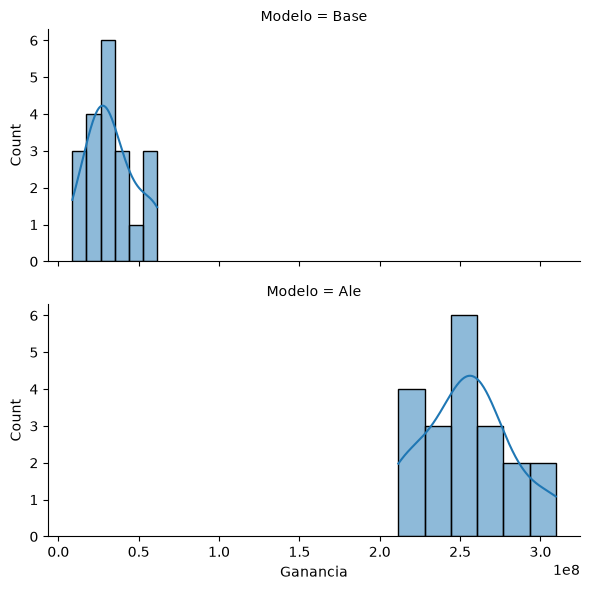

In [12]:
g = sns.FacetGrid(df_combined, row="Modelo", aspect=2)
g.map(sns.histplot, "Ganancia", kde=True)
plt.show()

* ¿Qué tan distintos son de los primero valores calculados con el modelo completo?
* ¿Con cuál se queda?
* ¿Por qué se produce semejante dispersión?
* ¿Cuál considera que es el "valor real"?

Podemos mirar la media

Estas preguntas se refieren al histograma/tabla que armaron con los 20 splits de StratifiedShuffleSplit, comparando contra los primeros números que viste (ganancia en train completo: 1.029.600.000 para model_base y 296.285.000 para model_ale).

¿Qué tan distintos son de los primeros valores calculados con el modelo completo?
Muy distintos, y en general mucho más bajos. Los primeros números eran ganancia medida en train (in-sample), inflada por memorización — sobre todo en model_base. Ahora, en cada uno de los 20 splits, se entrena con el 70% y se mide sobre el 30% que el modelo no vio en esa iteración. Vas a ver que las ganancias caen fuerte respecto al 1.03B/296M, y probablemente la brecha entre model_base y model_ale se achica muchísimo (o hasta se invierte en algunos splits) — confirmando que la diferencia original era en gran parte overfitting, no calidad real del modelo.

¿Con cuál se queda?
La trampa de la pregunta es que, mirando la distribución completa (el histograma), probablemente las dos se superpongan bastante. No hay una respuesta obvia de "éste gana siempre" — a veces un split favorece a model_base, a veces a model_ale. Elegir mirando un solo número (como hicimos al principio) es ingenuo; hay que mirar la distribución entera, no un punto.

¿Por qué se produce semejante dispersión?
Varias razones que se combinan:

Desbalance de clases: BAJA+2 es muy rara. En un fold de test de 30%, la cantidad exacta de casos BAJA+2 que caen ahí varía bastante de split a split, y como cada acierto vale $1.072.500, unos pocos casos de más o de menos mueven mucho la suma.
Inestabilidad de los árboles de decisión: son modelos de alta varianza. Entrenar con un 70% distinto de los datos en cada split puede producir árboles con splits internos bastante diferentes (sobre todo model_base, que no tiene restricciones).
Azar del split en sí: qué clientes específicos terminan en train vs test cambia en cada iteración, así que estás midiendo "ganancia con esta muestra particular de clientes", no un valor fijo.
¿Cuál considera que es el "valor real"?
No hay un único "valor real" observable directamente — el valor real sería la ganancia esperada del modelo sobre la población completa de clientes futuros (algo que nunca vas a conocer con certeza absoluta). Cada uno de los 20 splits es apenas una estimación ruidosa de ese valor poblacional. Por eso el texto dice "podemos mirar la media": promediando muchas estimaciones ruidosas independientes, el promedio converge hacia ese valor real mejor que cualquier estimación individual (ley de los grandes números).

Un detalle a tener en cuenta cuando llegues a esa celda de la media: ganancia() ya divide por prop=0.3 internamente al calcular cada valor de la lista. La celda siguiente hace mean_base/0.3 sobre esos valores que ya vienen corregidos — eso parece una doble corrección (dividir por 0.3 dos veces), lo cual infla el resultado de más. Vale la pena que lo chequees quiries cuando llegues ahí.

In [14]:
mean_base = df_combined[df_combined['Modelo'] == 'Base']['Ganancia'].mean()
mean_ale = df_combined[df_combined['Modelo'] == 'Ale']['Ganancia'].mean()

print(f"Ganancia media del modelo base:\t{mean_base/0.3:,.0f}")
print(f"Ganancia media del modelo ale:\t{mean_ale/0.3:,.0f}")

Ganancia media del modelo base:	110,458,333
Ganancia media del modelo ale:	848,100,000


In [ ]:
#claude sugiere: 
print(f"Ganancia media del modelo base:\t{mean_base:,.0f}")
print(f"Ganancia media del modelo ale:\t{mean_ale:,.0f}")

Ganancia media del modelo base:	33,137,500
Ganancia media del modelo ale:	254,430,000


claude:
hay una doble división.

Paso 1 — dentro de ganancia():


return ganancia_row(...).sum() / prop
Esta función ya devuelve el resultado corregido. Ejemplo: si sobre el 30% de test la suma cruda de aciertos/costos da 90.000, ganancia() devuelve 90.000 / 0.3 = 300.000. Ese 300.000 ya es "la ganancia estimada como si hubiera sido calculada sobre el 100% de la población".

Paso 2 — al armar results_base con train_and_evaluate:


ganancia_value = ganancia(m, X.iloc[test_index], y.iloc[test_index], prop=0.3)
Acá le pasás prop=0.3, así que ganancia_value ya sale corregido (siguiendo el ejemplo, 300.000). Eso es lo que termina en df_combined['Ganancia'] para cada uno de los 20 splits.

Paso 3 — el bloque que preguntaste:


mean_base = df_combined[df_combined['Modelo'] == 'Base']['Ganancia'].mean()
print(f"Ganancia media del modelo base:\t{mean_base/0.3:,.0f}")
mean_base es el promedio de esos 20 valores que ya vienen divididos por 0.3. Siguiendo el ejemplo, si el promedio de los 20 splits ya corregidos da 300.000, acá el código hace 300.000 / 0.3 = 1.000.000.

O sea, el valor final impreso terminó dividido por 0.3 dos veces (una adentro de ganancia(), otra en el print), lo que equivale a dividir por 0.3 × 0.3 = 0.09 en total. Eso multiplica el número final por ~11x en vez de por ~3.33x, así que el "Ganancia media" que te va a imprimir esa celda está inflada, no es el valor real.

Lo correcto sería simplemente:


print(f"Ganancia media del modelo base:\t{mean_base:,.0f}")
sin dividir de nuevo, porque mean_base ya está en la escala "población completa equivalente".


* Si no le gusta la media, ¿cómo más puede elegir entre dos modelos?

Muy interesante, pero lo importante es que sucedería en el **futuro**. Por este motivo nos guardamos el mes de **Mayo**.

claude:

Esta parte conecta dos ideas: primero te desafía a pensar más allá de la media, y después te explica por qué guardaron mayo aparte.

"Si no le gusta la media, ¿cómo más puede elegir entre dos modelos?"

La media es solo una forma de resumir la distribución de 20 valores de ganancia. Pero resumir a un solo número siempre pierde información, y hay otras formas de comparar dos distribuciones que capturan cosas distintas:

* Mediana: más robusta si hay valores extremos (outliers) que distorsionan la media.
* Dispersión / desvío estándar: dos modelos pueden tener medias parecidas, pero uno mucho más estable (menos varianza) que el otro. Ante la duda, capaz preferís el más predecible aunque su media sea un poco menor.
* Peor caso / percentil bajo (ej. percentil 5 o 10): si te importa el riesgo, mirás "en el peor 5% de los splits, ¿cuánto perdés como mínimo?" y elegís el modelo con mejor piso, no mejor promedio.
* Comparación pareada, split a split: como usaron la misma semilla/splits para ambos modelos, podés comparar directamente split por split y contar en cuántos de los 20 gana model_ale vs model_base (una especie de "win rate").
* Test estadístico (t-test pareado, Wilcoxon): para responder no solo "¿cuál tuvo mejor promedio?" sino "¿esa diferencia es estadísticamente significativa o podría ser puro ruido del muestreo?"
"Lo importante es qué sucedería en el futuro. Por eso guardamos mayo."

Todo lo que hicieron hasta acá — los 20 splits de StratifiedShuffleSplit — se hizo exclusivamente con datos de marzo. Es una simulación de variabilidad, pero sigue siendo información del pasado que ya tenían disponible. La pregunta que realmente importa en la competencia no es "¿qué tan bien le fue en marzo con distintos splits?" sino "¿qué tan bien le va a ir con clientes que todavía no existen en tus datos de entrenamiento?" — eso es literalmente el futuro.

Por eso separaron mes_test = 202105 (mayo) desde el principio y nunca lo tocaron para entrenar ni para elegir hiperparámetros. Mayo actúa como un sustituto de "el futuro real": es la prueba definitiva de si toda la elección de modelo hecha con marzo (media, dispersión, lo que sea que hayas usado) realmente predijo bien lo que iba a pasar, o si fue puro sobreajuste a la variabilidad de marzo.

In [16]:
X_futuro = data[data['foto_mes'] == mes_test]
y_futuro = X_futuro['clase_ternaria']
X_futuro = X_futuro.drop(columns=['clase_ternaria'])

Sobre el mes de Mayo, **debemos usar el modelo que se entreno sobre todos los datos**

In [18]:
ganancia_mayo_base = ganancia(model_base, X_futuro, y_futuro)
ganancia_mayo_ale = ganancia(model_ale, X_futuro, y_futuro)

print(f"Ganancia de modelo Base en Mayo:\t{ganancia_mayo_base:,.0f}")
print(f"Ganancia de modelo Ale en Mayo:\t{ganancia_mayo_ale:,.0f}")


Ganancia de modelo Base en Mayo:	12,485,000
Ganancia de modelo Ale en Mayo:	191,152,500


* ¿Cuál es mejor?
* ¿Por qué cree que el mejor es el mejor?
* ¿Hubiera elegido sabiamente únicamente con los datos de **Febrero**?

Claude:

¿Cuál es mejor?
model_ale, y no por poco: le saca más de 15x de ganancia a model_base en datos reales de mayo (datos que ninguno de los dos modelos vio jamás).

¿Por qué cree que el mejor es el mejor?
Acá se cierra el círculo con todo lo que vinimos discutiendo. Recordá los números en train: model_base (sin restricciones) tenía una ganancia "in-sample" absurdamente alta (1.029.600.000) comparado con model_ale (296.285.000, con max_depth=5 y min_samples_split=80). Esa diferencia era pura memorización: model_base ajustó ruido y particularidades específicas de los clientes de marzo que no significan nada en general.

Cuando lo enfrentás a mayo, ese ruido memorizado no sirve para nada — de hecho probablemente perjudica, porque el árbol tomó decisiones basadas en detalles espurios de marzo. model_ale, al estar regularizado (profundidad y tamaño mínimo de partición limitados), fue forzado a aprender patrones más generales y menos específicos de marzo, y esos patrones sí se sostienen dos meses después. Es el ejemplo de libro de overfitting vs generalización: el modelo que "ganaba" en train resultó ser mucho peor en el mundo real.

¿Hubiera elegido sabiamente únicamente con los datos de Febrero?
Esta pregunta apunta a algo distinto: la distancia temporal. Ya viste que usando marzo (el mes más cercano a mayo que tenían) hubo una brecha grande entre lo que el train sugería y lo que realmente pasó en mayo. Febrero está un mes más lejos todavía de mayo que marzo. En un problema como este (comportamiento de clientes de un banco: churn, consumo, contexto económico), cuanto más lejos en el tiempo estás del período que querés predecir, más probable es que las condiciones hayan cambiado (estacionalidad, campañas comerciales, contexto macro, etc.) — lo que se llama data drift. Entonces la respuesta esperada es: no, probablemente hubiera sido una elección aún menos confiable, porque estarías extrapolando patrones de un momento todavía más alejado del futuro que querés predecir, con mayor riesgo de que esos patrones ya no apliquen.

* ¿Cuál es mejor?
* ¿Por qué cree que el mejor es el mejor?
* ¿Hubiera elegido sabiamente únicamente con los datos de **Febrero**?

El mundo es un lugar **cruel** para los data scientists. El escenario anterior tampoco es el presente para los alumnos. Ya que la primera competencia sigue el modelo **kaggle** que divide el dataset en una parte **pública** y otra **privada**. Simulemos los efectos que produce en la decisión del mejor modelo en los leaderboards, simulando varios a la vez.


In [19]:
# podemos tomar más muestras, dado que solo vamos a scorear y eso es más rápido
sss_futuro = StratifiedShuffleSplit(n_splits=50,
                             test_size=0.3,
                             random_state=semilla)

ganancias_futuro_privada_ale = []
ganancias_futuro_privada_base = []
ganancias_futuro_publica_ale = []
ganancias_futuro_publica_base = []

for train_index, test_index in sss_futuro.split(X_futuro, y_futuro):
  ganancias_futuro_privada_ale.append(ganancia(model_ale, X_futuro.iloc[train_index], y_futuro.iloc[train_index], prop=0.7))
  ganancias_futuro_privada_base.append(ganancia(model_base, X_futuro.iloc[train_index], y_futuro.iloc[train_index], prop=0.7))
  ganancias_futuro_publica_ale.append(ganancia(model_ale, X_futuro.iloc[test_index], y_futuro.iloc[test_index], prop=0.3))
  ganancias_futuro_publica_base.append(ganancia(model_base, X_futuro.iloc[test_index], y_futuro.iloc[test_index], prop=0.3))


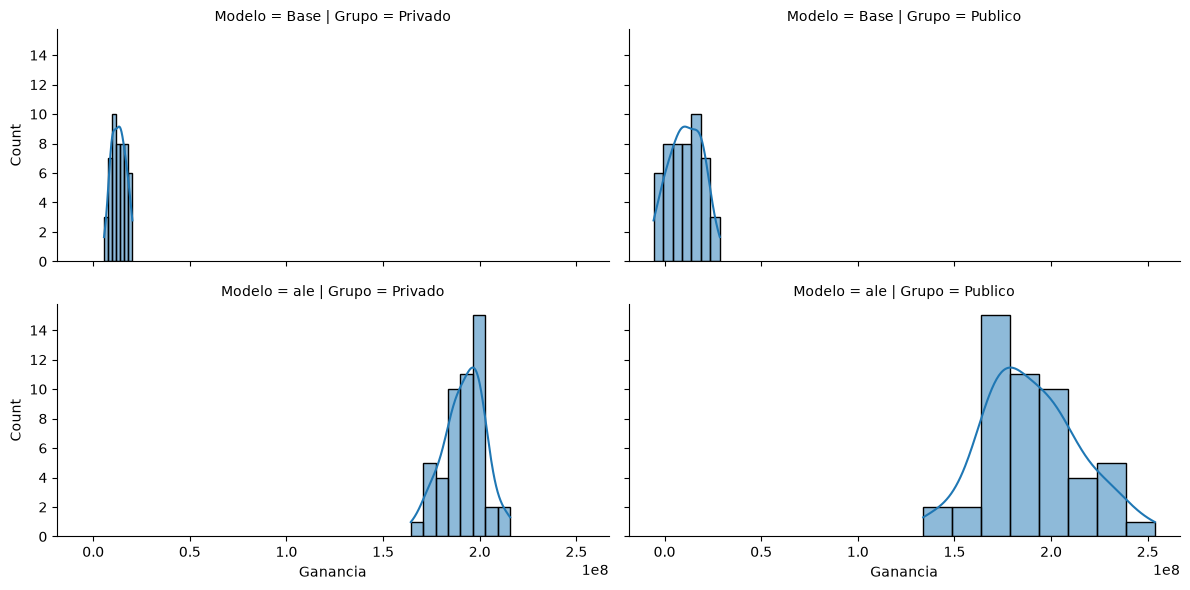

In [20]:
df_pred_1_ale = pd.DataFrame({'Ganancia': ganancias_futuro_privada_ale, 'Modelo': 'ale', 'Grupo': 'Privado'})
df_pred_2_ale = pd.DataFrame({'Ganancia': ganancias_futuro_publica_ale, 'Modelo': 'ale', 'Grupo': 'Publico'})
df_pred_1_base = pd.DataFrame({'Ganancia': ganancias_futuro_privada_base, 'Modelo': 'Base', 'Grupo': 'Privado'})
df_pred_2_base = pd.DataFrame({'Ganancia': ganancias_futuro_publica_base, 'Modelo': 'Base', 'Grupo': 'Publico'})

df_combined = pd.concat([df_pred_1_base, df_pred_2_base, df_pred_1_ale, df_pred_2_ale ])

g = sns.FacetGrid(df_combined, col="Grupo", row="Modelo", aspect=2)
g.map(sns.histplot, "Ganancia", kde=True)
plt.show()


In [21]:
mean_base_privado = df_combined[(df_combined['Modelo'] == 'Base') & (df_combined['Grupo'] == 'Privado')]['Ganancia'].mean()
mean_base_publico = df_combined[(df_combined['Modelo'] == 'Base') & (df_combined['Grupo'] == 'Publico')]['Ganancia'].mean()
mean_ale_privado = df_combined[(df_combined['Modelo'] == 'ale') & (df_combined['Grupo'] == 'Privado')]['Ganancia'].mean()
mean_ale_publico = df_combined[(df_combined['Modelo'] == 'ale') & (df_combined['Grupo'] == 'Publico')]['Ganancia'].mean()

print(f"Ganancia media del modelo base en privado: {mean_base_privado}")
print(f"Ganancia media del modelo base en publico: {mean_base_publico}")
print(f"Ganancia media del modelo ale en privado: {mean_ale_privado}")
print(f"Ganancia media del modelo ale en publico: {mean_ale_publico}")


Ganancia media del modelo base en privado: 13176428.57142857
Ganancia media del modelo base en publico: 10871666.666666668
Ganancia media del modelo ale en privado: 191844714.2857143
Ganancia media del modelo ale en publico: 189537333.3333333


* ¿Que significan estos resultados?

Dos cosas.

* El modelo ale, es un caso de **vagancia**. Cambiar 2 parámetros y esperar un cambio radical no es lo más inteligente que se puede hacer. Realmente hay que hacer un esfuerzo para separar las distribuciones.
* Elegir un modelo no es una tarea simple que se pueda hacer con una **certeza** absoluta.

Para encontrar buenos modelos una forma adecuada es la búsqueda de hiperparámetros. Podemos contar con las siguientes técnicas de búsqueda de hiperparámetros:

* **Grid Search**: Explora exhaustivamente todas las combinaciones posibles de hiperparámetros dentro de un conjunto predefinido de valores. Aunque es exhaustivo.

* **Random Search**: En lugar de probar todas las combinaciones posibles, selecciona un número aleatorio de combinaciones de hiperparámetros dentro de un rango predefinido.

* **Bayesian Optimization**: Este método construye un modelo probabilístico del rendimiento de los hiperparámetros y utiliza ese modelo para seleccionar los valores de hiperparámetros más prometedores.

* **Tree-structured Parzen Estimator (TPE)**: Una variante de la optimización bayesiana que utiliza estimadores de densidad basados en árboles (Parzen estimators) para modelar la probabilidad de los hiperparámetros óptimos. Es eficiente en la exploración de espacios de hiperparámetros complejos y se adapta bien a configuraciones con interdependencias entre los parámetros.

* **Genetic Algorithms**: Emplea principios de la evolución natural, como selección, cruce y mutación, para encontrar combinaciones óptimas de hiperparámetros. Es útil en espacios de búsqueda muy complejos, aunque puede ser computacionalmente costoso.

Todos son buenas opciones para la búsqueda de ... nah mentira, **grid search** apesta, si no me cree calcule el tiempo necesario para barrer el dominio de búsqueda.

Para la búsquedas de parámetros usaremos **Optuna**. **Optuna** es una librería poderosa y flexible, diseñada para realizar búsquedas eficientes y automatizadas.

* Utiliza casi todos los álgoritmos mencionados y más.

* Permite definir espacios de búsqueda complejos, incluyendo hiperparámetros categóricos, continuos, discretos y con dependencias condicionales.

* Ofrece un mecanismo de pruning o poda, que permite detener evaluaciones de configuraciones de hiperparámetros que no muestran promesas tempranas.

* Facilidad de Uso y Configuración.

* Proporciona herramientas de visualización integradas para analizar el progreso de la optimización, visualizar la importancia de los hiperparámetros y explorar las configuraciones probadas.

Buscaremos un mejor modelo de manera inteligente:

In [23]:

sss_opt = ShuffleSplit(n_splits=5, test_size=0.3, random_state=semilla)

def objective(trial, X, y, sss):
  # Limitaremos la busqueda a solo 3 hiperparámetros, pero puede poner los que quiera
  # criterion = trial.suggest_categorical('criterion', ['gini', 'entropy'])
  max_depth = trial.suggest_int('max_depth', 2, 20)
  min_samples_split = trial.suggest_int('min_samples_split', 2, 200)
  min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 20)
  # max_leaf_nodes = trial.suggest_int('max_leaf_nodes', 2, 20)

  def train_and_evaluate(train_index, test_index, X, y):
    m = DecisionTreeClassifier(
        # criterion=criterion,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        # max_leaf_nodes=max_leaf_nodes,
        random_state=semilla,
    )
    m.fit(X.iloc[train_index],y.iloc[train_index])
    ganancia_value = ganancia(m, X.iloc[test_index], y.iloc[test_index], prop=0.3)
    return ganancia_value

  results = Parallel(n_jobs=-1)(
      delayed(train_and_evaluate)(train_index, test_index, X, y)
      for train_index, test_index in sss.split(X)
  )

  return np.mean(results)

# Importante configurar la bbdd
storage_name = "sqlite:///C:\\Users\\alejandro\\dmeyf2026\\monday\\data\\optimization_tree.db"
#storage_name = "sqlite:////content/drive/MyDrive/DMEyF/2026/notebooks/data/optimization_tree.db"
study_name = "exp_101_decision-tree-opt"

study = optuna.create_study(
    direction="maximize",
    study_name=study_name,
    storage=storage_name,
    load_if_exists=True,
)

[I 2026-09-06 18:10:26,033] A new study created in RDB with name: exp_101_decision-tree-opt


Entre la muchas ventajas que tiene **Optuna** es que va almacenando las exploraciones en una base de datos, lo que nos permite continuar la búsqueda si esta se interrumpe.

In [27]:
# No quiero que se ejecute automaticamente, descomente y ejecute
study.optimize(lambda trial: objective(trial, X, y, sss_opt), n_trials=100)

[I 2026-09-06 18:12:34,351] Trial 0 finished with value: 264715000.00000006 and parameters: {'max_depth': 10, 'min_samples_split': 143, 'min_samples_leaf': 7}. Best is trial 0 with value: 264715000.00000006.
[I 2026-09-06 18:12:51,704] Trial 1 finished with value: 262001666.6666667 and parameters: {'max_depth': 14, 'min_samples_split': 191, 'min_samples_leaf': 2}. Best is trial 0 with value: 264715000.00000006.
[I 2026-09-06 18:13:05,902] Trial 2 finished with value: 246491666.66666666 and parameters: {'max_depth': 12, 'min_samples_split': 176, 'min_samples_leaf': 8}. Best is trial 0 with value: 264715000.00000006.
[I 2026-09-06 18:13:13,793] Trial 3 finished with value: 269243333.3333334 and parameters: {'max_depth': 5, 'min_samples_split': 29, 'min_samples_leaf': 3}. Best is trial 3 with value: 269243333.3333334.
[I 2026-09-06 18:13:20,307] Trial 4 finished with value: 272800000.00000006 and parameters: {'max_depth': 5, 'min_samples_split': 193, 'min_samples_leaf': 15}. Best is trial

A continuación veremos como fue el proceso de búsqueda a través de las visualizaciones que cuenta la herramienta (los gráficos son bastante autoexplicativos)

In [28]:
optuna.visualization.plot_optimization_history(study)

In [29]:
plot_slice(study)

In [30]:
plot_contour(study)

In [31]:
plot_contour(study, params=["max_depth", "min_samples_leaf"])

* Observe los valles y las montañas en las distintas combinaciones de parámetros. ¿Seguiría explorando?
* Si una montaña esta cerca del máximo del intervalo que exploración de un hiperparámetro. ¿Qué recomienda hacer?
* Existe alguna relación intrinseca entre le `min_sample_leaf` y `min_sample_split`? Puede mejorar esta búsqueda conectando estos parámetros?

Pasemos a analizar como le fue al mejor modelo en **Mayo**

In [32]:
# Obtener el mejor modelo
best_trial = study.best_trial
best_model_params = best_trial.params
print("Mejor modelo:", best_model_params)

model_best = DecisionTreeClassifier(**best_model_params, random_state=semilla)
model_best.fit(X, y)

print(f"Ganancia del mejor modelo: {ganancia(model_best, X_futuro, y_futuro)}")

Mejor modelo: {'max_depth': 10, 'min_samples_split': 195, 'min_samples_leaf': 2}
Ganancia del mejor modelo: 204545000.0


Es mejor que los anteriores! y solo por una hora de procesamiento!!!

¿qué más podemos pedir por tan poco?

Veamos comparados con los anteriores que tanto mejor es...


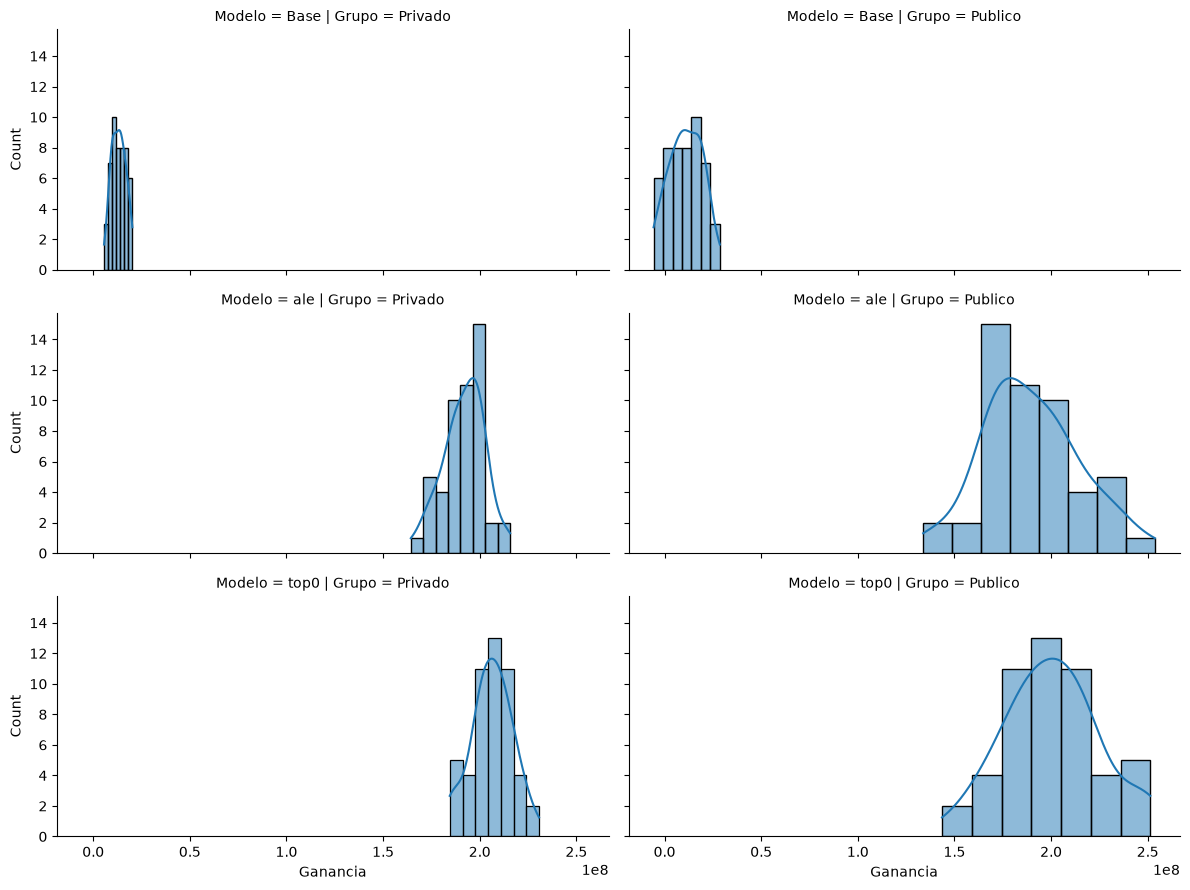

In [33]:
ganancias_futuro_top0_publica = []
ganancias_futuro_top0_privado = []
for train_index, test_index in sss_futuro.split(X_futuro, y_futuro):
  ganancias_futuro_top0_publica.append(ganancia(model_best, X_futuro.iloc[test_index], y_futuro.iloc[test_index], prop=0.3))
  ganancias_futuro_top0_privado.append(ganancia(model_best, X_futuro.iloc[train_index], y_futuro.iloc[train_index], prop=0.7))

df_pred_top0_privado = pd.DataFrame({'Ganancia': ganancias_futuro_top0_privado, 'Modelo': 'top0', 'Grupo': 'Privado'})
df_pred_top0_publica = pd.DataFrame({'Ganancia': ganancias_futuro_top0_publica, 'Modelo': 'top0', 'Grupo': 'Publico'})

df_combined = pd.concat([df_pred_1_base,
                         df_pred_2_base,
                         df_pred_1_ale,
                         df_pred_2_ale,
                         df_pred_top0_privado,
                         df_pred_top0_publica])

g = sns.FacetGrid(df_combined, col="Grupo", row="Modelo", aspect=2)
g.map(sns.histplot, "Ganancia", kde=True)
plt.show()

Bueno, no parece mucho mejor. Es tan solo mejor. Vamos moviendo de a poco la vara.

* ¿Qué se puede hacer para mejorarlo? Debate con la clase abierta


## Tarea:

* Ejecute todo de nuevo para su semilla y los hiperparámetros que considere.
* Ya tiene la búsqueda de Optuna. Duda existencial: Dado que no hay tanta distancia entre el primer modelo y los subsiguientes en optuna y que a su vez hicimos apenas 5 muestreos, no será posible que el mejor modelo en SSS no sea el mejor en el privado de **Mayo**?
    * Quédese con los top 5 de optuna. Use más muestras para cada modelo (20 o más)
    * Calcule la ganancia y su distribución en los conjuntos de validación
    * Cómo son las medias? ayudan a elegir el mejor modelo en el privado? con que confianza?
    * Sólo mirando la distribución del muestreo de validación, tiene herramientas para elegir el mejor modelo en el privado?
    * Puede pasar que comparando 2 modelos uno le gane al otro en el público, pero no así en el privado? En que porcentaje pasa?
         
Colaboración:
* Recuerde compartir con tus compañeros los nuevos scripts que hayas generado y las configuraciones que hayas probado por Zulip